# Yüksek Performanslı Yol Hasarı Sınıflandırma

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms
from pathlib import Path
import time

NUM_WORKERS = 0

# 1. Veri Yükleyici Fonksiyonu

In [2]:
def create_dataloaders(train_dir, test_dir, train_transform, test_transform, batch_size, num_workers=NUM_WORKERS):
    train_data = datasets.ImageFolder(train_dir, transform=train_transform)
    test_data = datasets.ImageFolder(test_dir, transform=test_transform)
    class_names = train_data.classes
    train_dataloader = DataLoader(train_data, batch_size=batch_size, num_workers=num_workers, shuffle=True)
    test_dataloader = DataLoader(test_data, batch_size=batch_size, num_workers=num_workers, shuffle=False)
    return train_dataloader, test_dataloader, class_names

# 2. Eğitim ve Test Adımları

In [3]:
def train_step(model, dataloader, loss_fn, optimizer, device):
    model.train()
    train_loss, train_acc = 0, 0
    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)
    return train_loss / len(dataloader), train_acc / len(dataloader)

def test_step(model, dataloader, loss_fn, device):
    model.eval()
    test_loss, test_acc = 0, 0
    with torch.inference_mode():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            test_pred_logits = model(X)
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += (test_pred_labels == y).sum().item() / len(test_pred_labels)
    return test_loss / len(dataloader), test_acc / len(dataloader)

# 3. Genel Eğitim Döngüsü

In [4]:
def train(model, train_dataloader, test_dataloader, optimizer, device, epochs=10):
    loss_fn = nn.CrossEntropyLoss()
    best_test_acc = 0
    for epoch in range(epochs):
        train_loss, train_acc = train_step(model, train_dataloader, loss_fn, optimizer, device)
        test_loss, test_acc = test_step(model, test_dataloader, loss_fn, device)
        print(f"Epoch: {epoch+1} | train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f} | test_loss: {test_loss:.4f} | test_acc: {test_acc:.4f}")
        if test_acc > best_test_acc:
            best_test_acc = test_acc
    return best_test_acc


# 4. Model Kurucuları (Fine-Tuning)

In [5]:
def build_efficientnet(device, num_classes):
    weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
    model = torchvision.models.efficientnet_b0(weights=weights).to(device)
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[7].parameters():
        param.requires_grad = True
    for param in model.features[8].parameters():
        param.requires_grad = True
    model.classifier = torch.nn.Sequential(
        torch.nn.Dropout(p=0.2, inplace=True),
        torch.nn.Linear(in_features=1280, out_features=num_classes, bias=True)
    ).to(device)
    return model

def build_resnet50(device, num_classes):
    weights = torchvision.models.ResNet50_Weights.DEFAULT
    model = torchvision.models.resnet50(weights=weights).to(device)
    for param in model.parameters():
        param.requires_grad = False
    for param in model.layer4.parameters():
        param.requires_grad = True
    model.fc = torch.nn.Linear(in_features=model.fc.in_features, out_features=num_classes, bias=True).to(device)
    return model


# 5. Veri Hazırlığı ve Çoğaltma (Data Augmentation)

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Kullanilan Cihaz: {device.upper()}")

image_path = Path("road_damage")
train_dir = image_path / "train"
test_dir = image_path / "test"

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_loader, test_loader, class_names = create_dataloaders(
    train_dir=train_dir, 
    test_dir=test_dir, 
    train_transform=train_transform, 
    test_transform=test_transform, 
    batch_size=32
)
print(f"Siniflar: {class_names}")

Kullanilan Cihaz: CUDA
Siniflar: ['Crack', 'Manhole', 'Pothole']


# 6. EfficientNet-B0 Testi

In [7]:
print("--- MODEL 1: EfficientNet-B0 (Fine-Tuned) ---")
eff_model = build_efficientnet(device, len(class_names))
eff_optimizer = torch.optim.AdamW(eff_model.parameters(), lr=1e-4, weight_decay=1e-2)
eff_best_acc = train(model=eff_model, train_dataloader=train_loader, test_dataloader=test_loader, optimizer=eff_optimizer, device=device, epochs=10)

--- MODEL 1: EfficientNet-B0 (Fine-Tuned) ---
Epoch: 1 | train_loss: 0.8569 | train_acc: 0.5972 | test_loss: 0.8303 | test_acc: 0.6082
Epoch: 2 | train_loss: 0.7237 | train_acc: 0.6764 | test_loss: 0.7733 | test_acc: 0.6575
Epoch: 3 | train_loss: 0.6759 | train_acc: 0.7129 | test_loss: 0.6884 | test_acc: 0.7054
Epoch: 4 | train_loss: 0.6468 | train_acc: 0.7173 | test_loss: 0.6698 | test_acc: 0.7228
Epoch: 5 | train_loss: 0.6273 | train_acc: 0.7272 | test_loss: 0.6727 | test_acc: 0.7134
Epoch: 6 | train_loss: 0.6077 | train_acc: 0.7319 | test_loss: 0.6505 | test_acc: 0.7138
Epoch: 7 | train_loss: 0.6005 | train_acc: 0.7390 | test_loss: 0.6221 | test_acc: 0.7371
Epoch: 8 | train_loss: 0.5605 | train_acc: 0.7634 | test_loss: 0.6566 | test_acc: 0.7232
Epoch: 9 | train_loss: 0.5825 | train_acc: 0.7396 | test_loss: 0.6193 | test_acc: 0.7457
Epoch: 10 | train_loss: 0.5511 | train_acc: 0.7715 | test_loss: 0.5949 | test_acc: 0.7380


# 7. ResNet50 Testi

In [8]:
print("\n--- MODEL 2: ResNet50 (Fine-Tuned) ---")
res_model = build_resnet50(device, len(class_names))
res_optimizer = torch.optim.AdamW(res_model.parameters(), lr=1e-4, weight_decay=1e-2)
res_best_acc = train(model=res_model, train_dataloader=train_loader, test_dataloader=test_loader, optimizer=res_optimizer, device=device, epochs=10)


--- MODEL 2: ResNet50 (Fine-Tuned) ---
Epoch: 1 | train_loss: 0.8055 | train_acc: 0.6374 | test_loss: 0.7984 | test_acc: 0.6666
Epoch: 2 | train_loss: 0.6370 | train_acc: 0.7255 | test_loss: 0.7696 | test_acc: 0.6672
Epoch: 3 | train_loss: 0.5784 | train_acc: 0.7515 | test_loss: 0.6794 | test_acc: 0.7130
Epoch: 4 | train_loss: 0.5374 | train_acc: 0.7691 | test_loss: 0.6289 | test_acc: 0.7308
Epoch: 5 | train_loss: 0.4965 | train_acc: 0.7846 | test_loss: 0.6764 | test_acc: 0.7155
Epoch: 6 | train_loss: 0.4706 | train_acc: 0.8092 | test_loss: 0.6800 | test_acc: 0.7378
Epoch: 7 | train_loss: 0.4546 | train_acc: 0.8071 | test_loss: 0.6035 | test_acc: 0.7510
Epoch: 8 | train_loss: 0.4280 | train_acc: 0.8270 | test_loss: 0.6276 | test_acc: 0.7451
Epoch: 9 | train_loss: 0.4166 | train_acc: 0.8259 | test_loss: 0.6486 | test_acc: 0.7346
Epoch: 10 | train_loss: 0.4005 | train_acc: 0.8310 | test_loss: 0.6100 | test_acc: 0.7516


# 8. Sonuçların Kıyaslanması

In [9]:
print("\n================ Ozet ==================")
print(f"EfficientNet-B0 En Iyi Test Dogrulugu: %{eff_best_acc*100:.2f}")
print(f"ResNet50 En Iyi Test Dogrulugu       : %{res_best_acc*100:.2f}")
if eff_best_acc > res_best_acc:
    print("Kazanan: EfficientNet-B0! 🏆")
elif res_best_acc > eff_best_acc:
    print("Kazanan: ResNet50! 🏆")
else:
    print("Iki model de ayni performansi gosterdi! 🤝")


================ Ozet ==================
EfficientNet-B0 En Iyi Test Dogrulugu: %74.57
ResNet50 En Iyi Test Dogrulugu       : %75.16
Kazanan: ResNet50! 🏆


# Fotoğraf Yükleyip Tahmin Yaptırma (Inference)

In [10]:
import matplotlib.pyplot as plt
from PIL import Image

def predict_image(image_path, model, transform, class_names, device):
    try:
        # Resmi Yükle
        img = Image.open(image_path).convert("RGB")
        
        # Modele uygun hale getir (Test transformasyonunu kullanıyoruz)
        img_tensor = transform(img).unsqueeze(0).to(device)
        
        # Tahmin Et
        model.eval()
        with torch.inference_mode():
            pred_logits = model(img_tensor)
            pred_probs = torch.softmax(pred_logits, dim=1)
            pred_label = torch.argmax(pred_probs, dim=1).item()
            
        predicted_class = class_names[pred_label]
        confidence = pred_probs[0][pred_label].item() * 100
        
        # Resmi ve Sonucu Göster
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.title(f"Tahmin: {predicted_class} | Güven: %{confidence:.2f}", fontsize=14, color='blue')
        plt.axis("off")
        plt.show()
        
    except Exception as e:
        print(f"Hata oluştu: {e}")

# KULLANIM ÖRNEĞİ:
# Kendi çektiğin veya test klasöründen bir fotoğrafın yolunu buraya yaz:
# ornek_resim_yolu = str(test_dir / "Crack" / "ornek_resim.jpg")
# predict_image(ornek_resim_yolu, eff_model, test_transform, class_names, device)

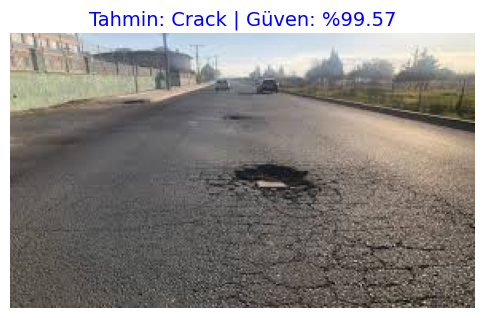

In [11]:
ornek_resim_yolu = "images.jpg"
predict_image(ornek_resim_yolu, res_model, test_transform, class_names, device)

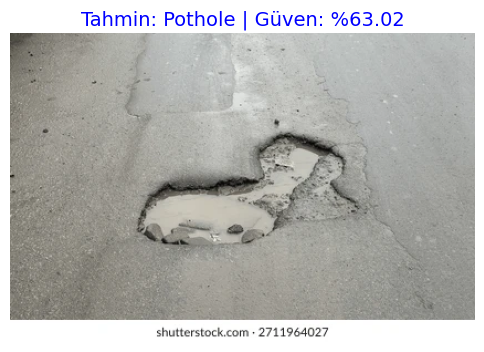

In [12]:
ornek_resim_yolu = "large-pothole-sits-on-road-260nw-2711964027.webp"
predict_image(ornek_resim_yolu, res_model, test_transform, class_names, device)

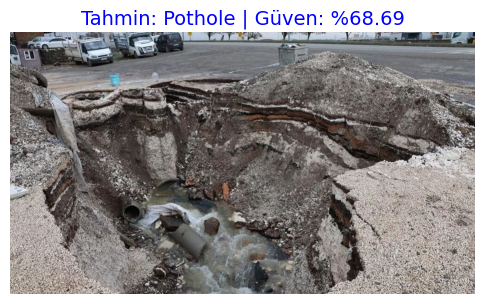

In [15]:
ornek_resim_yolu = "diyarbakirda-ana-yolda-dev-cukur-gorenler-sasti-kaldi.webp"
predict_image(ornek_resim_yolu, res_model, test_transform, class_names, device)

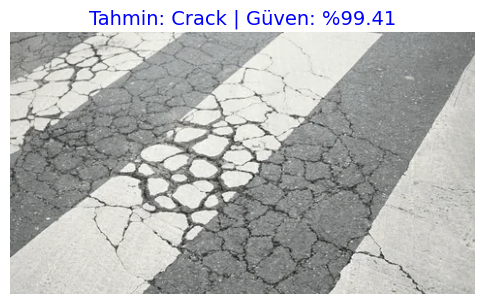

In [16]:
ornek_resim_yolu = "1.webp"
predict_image(ornek_resim_yolu, res_model, test_transform, class_names, device)

In [17]:
# EGITILMIS MODELI KAYDET
def save_model_checkpoint(model, class_names, model_name, save_path):
    checkpoint = {
        "model_state_dict": model.state_dict(),
        "metadata": {
            "class_names": class_names,
            "model_name": model_name
        }
    }
    torch.save(checkpoint, save_path)
    print(f"Model kaydedildi: {save_path}")

# ResNet50 icin:
save_model_checkpoint(res_model, class_names, "resnet50", "resnet50_road_damage.pt")

# EfficientNet icin kaydetmek istersen:
# save_model_checkpoint(eff_model, class_names, "efficientnet_b0", "efficientnet_road_damage.pt")


Model kaydedildi: resnet50_road_damage.pt
